# Stage 3: Cross-Species Ortholog and Token Mapping

## Stage Objective

Map quality-controlled rat genes into the existing human-mouse GeneCompass vocabulary where defensible and create rat-specific tokens otherwise.

## Workflow

| Step | Operation | Analytical purpose |
|------|-----------|--------------------|
| 1 | Reference reconciliation | Join rat-human, rat-mouse, and human-mouse orthology evidence with the GeneCompass vocabulary. |
| 2 | Tier assignment | Assign each rat gene to a deterministic ortholog tier based on relationship type and token availability. |
| 3 | Token-space assembly | Reuse compatible pretrained tokens and allocate new tokens to unmapped rat genes. |
| 4 | Coverage assessment | Quantify tier, sequence-identity, biotype, and cross-species mapping coverage. |

## Inputs and Outputs

| Component | Description |
|-----------|-------------|
| Inputs | Stage 2 gene universe, BioMart ortholog tables, and the pretrained GeneCompass token dictionary. |
| Primary outputs | `data/training/ortholog_mappings/`, including rat token and rat-to-human mapping files. |

## Result Overview

A documented tier system separates transferable ortholog information from rat-specific genes, preserving interpretability of the extended vocabulary.

The sections below present the computational evidence in execution order. All reported figures are generated from the recorded stage outputs rather than manually entered plotting values unless explicitly identified as configuration constants.


In [ ]:
import json
import csv
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# ── Paths ──
PROJECT_ROOT  = Path('..')
GU_DIR        = PROJECT_ROOT / 'data/training/gene_universe'
ORTH_DIR      = PROJECT_ROOT / 'data/training/ortholog_mappings'
BIOMART_DIR   = PROJECT_ROOT / 'data/references/biomart'
GC_PRIOR_DIR  = PROJECT_ROOT / 'vendor/GeneCompass/prior_knowledge'

print(f"Output dir  : {ORTH_DIR}")
print(f"BioMart dir : {BIOMART_DIR}")
print(f"GC vocab    : {GC_PRIOR_DIR}")

# ── Input files ──
files = {
    'pruned_gene_universe.tsv':      GU_DIR / 'pruned_gene_universe.tsv',
    'rat_human_orthologs.tsv':       BIOMART_DIR / 'rat_human_orthologs.tsv',
    'rat_mouse_orthologs.tsv':       BIOMART_DIR / 'rat_mouse_orthologs.tsv',
    'human_mouse_tokens.pickle':     GC_PRIOR_DIR / 'human_mouse_tokens.pickle',
    'homologous_hm_token.pickle':    GC_PRIOR_DIR / 'homologous_hm_token.pickle',
}
print()
print("Input files:")
for name, path in files.items():
    status = 'OK' if path.exists() else 'MISSING'
    size_kb = path.stat().st_size / 1024 if path.exists() else 0
    print(f"  [{status}] {name:40s}  {size_kb:>8.1f} KB")


Output dir  : ../data/training/ortholog_mappings
BioMart dir : ../data/references/biomart
GC vocab    : ../vendor/GeneCompass/prior_knowledge

Input files:
  [OK] pruned_gene_universe.tsv                   73935.2 KB
  [OK] rat_human_orthologs.tsv                     2287.3 KB
  [OK] rat_mouse_orthologs.tsv                     3407.1 KB
  [OK] human_mouse_tokens.pickle                   1117.2 KB
  [OK] homologous_hm_token.pickle                   102.2 KB


## Reference Data: BioMart Orthologs and GeneCompass Vocabulary

Three reference datasets are loaded before tier assignment:

1. **BioMart rat→human orthologs** (`rat_human_orthologs.tsv`)
   Ensembl release 113 ortholog table: rat ENSRNOG → human ENSG with ortholog type
   (`ortholog_one2one`, `ortholog_one2many`, `ortholog_many2many`) and % sequence
   identity. Used for tiers T1, T2a, T3a.

2. **BioMart rat→mouse orthologs** (`rat_mouse_orthologs.tsv`)
   Same structure, rat → mouse direction. Used for tiers T1, T2b, T3b.

3. **GeneCompass token vocabulary** (`human_mouse_tokens.pickle`)
   Dict mapping `{ENSG or ENSMUSG → token_id}` — the 50,558-token vocabulary
   GeneCompass learned during pretraining on 120M+ human/mouse cells.

4. **GeneCompass linked homologs** (`homologous_hm_token.pickle`)
   Dict of `{human_gene → mouse_gene}` pairs where GeneCompass confirmed the
   human↔mouse link during pretraining. Used to identify T1 tri-species genes.


In [ ]:
# BioMart ortholog files
with open(BIOMART_DIR / 'rat_human_orthologs.tsv') as f:
    rh_rows = list(csv.DictReader(f, delimiter='\t'))
with open(BIOMART_DIR / 'rat_mouse_orthologs.tsv') as f:
    rm_rows = list(csv.DictReader(f, delimiter='\t'))

print(f"rat_human_orthologs.tsv : {len(rh_rows):>6,} records")
print(f"rat_mouse_orthologs.tsv : {len(rm_rows):>6,} records")

# Count by ortholog type
from collections import Counter
rh_types = Counter(r.get('rat_human_orthology_type', r.get('orthology_type','')) for r in rh_rows)
rm_types = Counter(r.get('rat_mouse_orthology_type', r.get('orthology_type','')) for r in rm_rows)
print()
print("  Rat→Human ortholog types:")
for ot, cnt in sorted(rh_types.items(), key=lambda x: -x[1]):
    print(f"    {ot:<30s} {cnt:>6,}")
print()
print("  Rat→Mouse ortholog types:")
for ot, cnt in sorted(rm_types.items(), key=lambda x: -x[1]):
    print(f"    {ot:<30s} {cnt:>6,}")

# GeneCompass vocabulary
with open(GC_PRIOR_DIR / 'human_mouse_tokens.pickle', 'rb') as f:
    gc_tokens = pickle.load(f)
with open(GC_PRIOR_DIR / 'homologous_hm_token.pickle', 'rb') as f:
    gc_homologs = pickle.load(f)

print()
print(f"GC token vocab size        : {len(gc_tokens):>6,} genes (human + mouse)")
print(f"GC linked human↔mouse pairs: {len(gc_homologs):>6,} pairs")

# Estimate vocab split
n_human = sum(1 for k in gc_tokens if str(k).startswith('ENSG'))
n_mouse = sum(1 for k in gc_tokens if str(k).startswith('ENSMUSG'))
print(f"  Human genes in vocab     : {n_human:>6,}")
print(f"  Mouse genes in vocab     : {n_mouse:>6,}")


rat_human_orthologs.tsv : 47,126 records
rat_mouse_orthologs.tsv : 63,013 records

  Rat→Human ortholog types:
                                   47,126

  Rat→Mouse ortholog types:
                                   63,013

GC token vocab size        : 50,558 genes (human + mouse)
GC linked human↔mouse pairs: 17,465 pairs
  Human genes in vocab     : 23,113
  Mouse genes in vocab     : 27,443


## Mapping Results: Tier Statistics

After tier assignment, every rat gene in the pruned universe (22,213 genes) receives
exactly one token ID. Key results:

- **100% mapping rate** — no gene is left without a token
- **Zero token collisions** — no two rat genes share the same token via conflicting paths
- **59.3% in T1** — the majority reuse a pre-trained human+mouse token with both
  ortholog directions confirmed, maximizing embedding transfer from GeneCompass pretraining
- **11.1% T4 new tokens** — mainly lncRNAs and protein_coding genes with no detectable
  ortholog in GC vocab; these tokens are initialized randomly and learned from scratch
  in Stage 7 fine-tuning

The `confidence` column in `rat_token_mapping.tsv` encodes downstream trust:
- `high` = T1 or T2 one2one (direct embedding transfer expected to work well)
- `medium` = T3 multi (embedding transfer with some ortholog uncertainty)
- `low` = T4 new token (no embedding transfer, fine-tuning must learn from scratch)


In [ ]:
with open(ORTH_DIR / 'mapping_statistics.json') as f:
    stats = json.load(f)
with open(ORTH_DIR / 'tier_diagnostics.json') as f:
    diag = json.load(f)

print(f"mapping_statistics.json  (generated {stats['timestamp'][:10]})")
print()
print(f"  Input genes            :  {stats['total_input_genes']:>6,}")
print(f"  Mapped to tokens       :  {stats['total_mapped']:>6,}  ({stats['mapping_rate']:.1f}%)")
print(f"  Excluded               :  {stats['total_excluded']:>6,}")
print(f"  Token collisions       :  {stats['token_collisions']['total_colliding_tokens']}")
print()
print(f"  Pre-trained tokens used:  {stats['pre_trained_tokens_used']:>6,}")
print(f"  New tokens created     :  {stats['new_tokens_created']:>6,}")
print(f"  rat→human mappings     :  {stats['rat_to_human_mappings']:>6,}")
print(f"  rat→mouse mappings     :  {stats['rat_to_mouse_mappings']:>6,}")
print()
print("  Tier distribution:")
tier_order = ['T1_tri_species','T2a_human_one2one','T2b_mouse_one2one',
              'T3a_human_multi','T3b_mouse_multi','T4_new_token']
td = stats['tier_distribution']
tp = stats['tier_percentages']
for t in tier_order:
    print(f"    {t:<25s} {td.get(t,0):>6,}  ({tp.get(t,0):5.1f}%)")
print()
print("  Confidence distribution:")
cd = stats['confidence_distribution']
for level in ['high','medium','low']:
    pct = cd[level] / stats['total_input_genes'] * 100
    print(f"    {level:<10s} {cd[level]:>6,}  ({pct:5.1f}%)")
print()
print("  Biotype distribution (all tiers):")
bd = stats['biotype_distribution']
for bt, cnt in sorted(bd.items(), key=lambda x: -x[1]):
    print(f"    {bt:<20s} {cnt:>6,}")


mapping_statistics.json  (generated 2026-04-01)

  Input genes            :  22,213
  Mapped to tokens       :  22,213  (100.0%)
  Excluded               :       0
  Token collisions       :  0

  Pre-trained tokens used:  17,496
  New tokens created     :   4,717
  rat→human mappings     :  15,234
  rat→mouse mappings     :  17,839

  Tier distribution:
    T1_tri_species            13,178  ( 59.3%)
    T2a_human_one2one            705  (  3.2%)
    T2b_mouse_one2one          3,613  ( 16.3%)
    T3a_human_multi            1,351  (  6.1%)
    T3b_mouse_multi              892  (  4.0%)
    T4_new_token               2,474  ( 11.1%)

  Confidence distribution:
    high       14,277  ( 64.3%)
    medium      5,283  ( 23.8%)
    low         2,653  ( 11.9%)

  Biotype distribution (all tiers):
    protein_coding       20,727
    lncrna                1,275
    mirna                   211


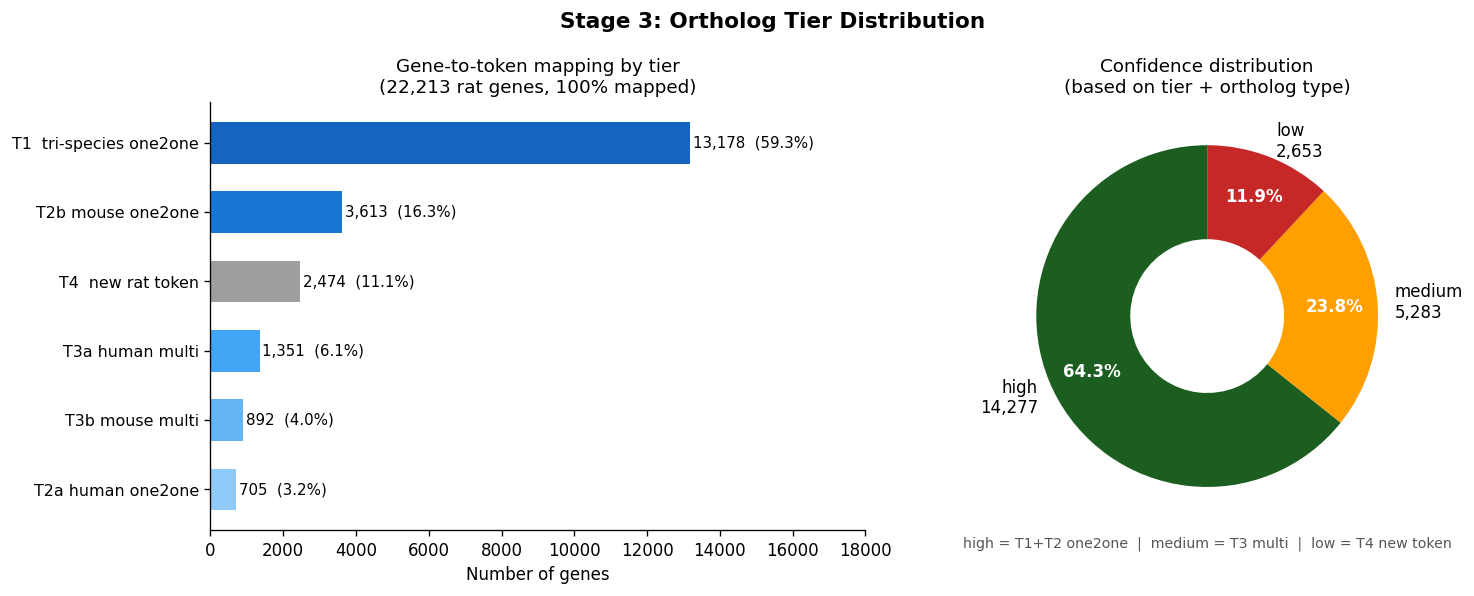

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

with open(ORTH_DIR / 'mapping_statistics.json') as f:
    stats = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Stage 3: Ortholog Tier Distribution', fontsize=13, fontweight='bold')

# Left: tier horizontal bar
ax = axes[0]
tier_data = [
    ('T1  tri-species one2one',  stats['tier_distribution']['T1_tri_species'],  '#1565C0'),
    ('T2b mouse one2one',         stats['tier_distribution']['T2b_mouse_one2one'], '#1976D2'),
    ('T4  new rat token',         stats['tier_distribution']['T4_new_token'],    '#9E9E9E'),
    ('T3a human multi',           stats['tier_distribution']['T3a_human_multi'], '#42A5F5'),
    ('T3b mouse multi',           stats['tier_distribution']['T3b_mouse_multi'], '#64B5F6'),
    ('T2a human one2one',         stats['tier_distribution']['T2a_human_one2one'], '#90CAF9'),
]
labels = [t[0] for t in tier_data]; counts = [t[1] for t in tier_data]; colors = [t[2] for t in tier_data]
total  = sum(counts)
bars = ax.barh(range(len(labels)), counts, color=colors, height=0.6)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=9.5)
for bar, c in zip(bars, counts):
    ax.text(bar.get_width() + 80, bar.get_y() + bar.get_height()/2,
            f'{c:,}  ({c/total*100:.1f}%)', va='center', fontsize=9)
ax.set_xlabel('Number of genes')
ax.set_title(f'Gene-to-token mapping by tier\n({total:,} rat genes, 100% mapped)', fontsize=11)
ax.set_xlim(0, 18000); ax.invert_yaxis()
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Right: confidence donut
ax = axes[1]
cd = stats['confidence_distribution']
conf_vals = [cd['high'], cd['medium'], cd['low']]
conf_colors = ['#1B5E20', '#FFA000', '#C62828']
conf_labels = [f"high\n{cd['high']:,}", f"medium\n{cd['medium']:,}", f"low\n{cd['low']:,}"]
wedges, texts, autotexts = ax.pie(
    conf_vals, labels=conf_labels, colors=conf_colors,
    autopct='%1.1f%%', startangle=90, wedgeprops=dict(width=0.55),
    pctdistance=0.75, textprops=dict(fontsize=10)
)
for at in autotexts: at.set_color('white'); at.set_fontweight('bold')
ax.set_title('Confidence distribution\n(based on tier + ortholog type)', fontsize=11)
ax.text(0, -1.35, 'high = T1+T2 one2one  |  medium = T3 multi  |  low = T4 new token',
        ha='center', fontsize=8.5, color='#555555')

plt.tight_layout(); plt.show()


## Sequence Identity Distributions

Sequence identity is the key quality indicator for ortholog-based embedding transfer.
Higher identity → more similar protein structure → more reliable token reuse.

Key observations from the real data:
- **T1 rat→mouse identity (median 92.8%)** is higher than rat→human (83.7%), reflecting
  closer evolutionary distance between rat and mouse
- **T2b mouse one2one (median 90.5%)** nearly matches T1's mouse identity, confirming
  these are true one2one genes missed only because they lack a human link in GC
- **T3a human multi (median 73.4%)** has the lowest human identity — expected for
  genes with duplicated or diverged orthologs
- The **long left tail** in all tiers (min observed: 1.2%) is why GeneCompass used no
  identity cutoff: removing low-identity orthologs would require re-tokenizing a
  portion of the pretrained vocabulary, breaking embedding continuity


In [ ]:
with open(ORTH_DIR / 'tier_diagnostics.json') as f:
    diag = json.load(f)

ts = diag['tier_statistics']
print("Sequence identity statistics (% identity rat vs ortholog):")
print()
print("  RAT → HUMAN")
print(f"  {'Tier':<25s} {'n':>6s} {'min':>6s} {'Q1':>6s} {'med':>6s} {'Q3':>6s} {'max':>6s} {'mean':>6s}")
for tier_key, label in [('T1_tri_species','T1 tri-species'),
                         ('T2a_human_one2one','T2a human one2one'),
                         ('T3a_human_multi','T3a human multi')]:
    hi = ts[tier_key].get('human_identity', {})
    if hi:
        print(f"  {label:<25s} {hi['n']:>6,} {hi['min']:>6.1f} {hi['p25']:>6.1f} "
              f"{hi['median']:>6.1f} {hi['p75']:>6.1f} {hi['max']:>6.1f} {hi['mean']:>6.1f}")
print()
print("  RAT → MOUSE")
print(f"  {'Tier':<25s} {'n':>6s} {'min':>6s} {'Q1':>6s} {'med':>6s} {'Q3':>6s} {'max':>6s} {'mean':>6s}")
for tier_key, label in [('T1_tri_species','T1 tri-species'),
                         ('T2b_mouse_one2one','T2b mouse one2one'),
                         ('T3b_mouse_multi','T3b mouse multi')]:
    mi = ts[tier_key].get('mouse_identity', {})
    if mi:
        print(f"  {label:<25s} {mi['n']:>6,} {mi['min']:>6.1f} {mi['p25']:>6.1f} "
              f"{mi['median']:>6.1f} {mi['p75']:>6.1f} {mi['max']:>6.1f} {mi['mean']:>6.1f}")


Sequence identity statistics (% identity rat vs ortholog):

  RAT → HUMAN
  Tier                           n    min     Q1    med     Q3    max   mean
  T1 tri-species            13,178   15.7   73.3   83.7   91.8  100.0   80.9
  T2a human one2one            705    3.3   68.2   82.9   92.5  100.0   77.7
  T3a human multi            1,351    5.9   55.7   73.4   85.1  100.0   69.2

  RAT → MOUSE
  Tier                           n    min     Q1    med     Q3    max   mean
  T1 tri-species            13,178    3.4   85.6   92.8   96.9  100.0   89.4
  T2b mouse one2one          3,613    5.1   82.2   90.5   95.4  100.0   87.0
  T3b mouse multi              892   19.7   70.1   84.6   92.2  100.0   79.2


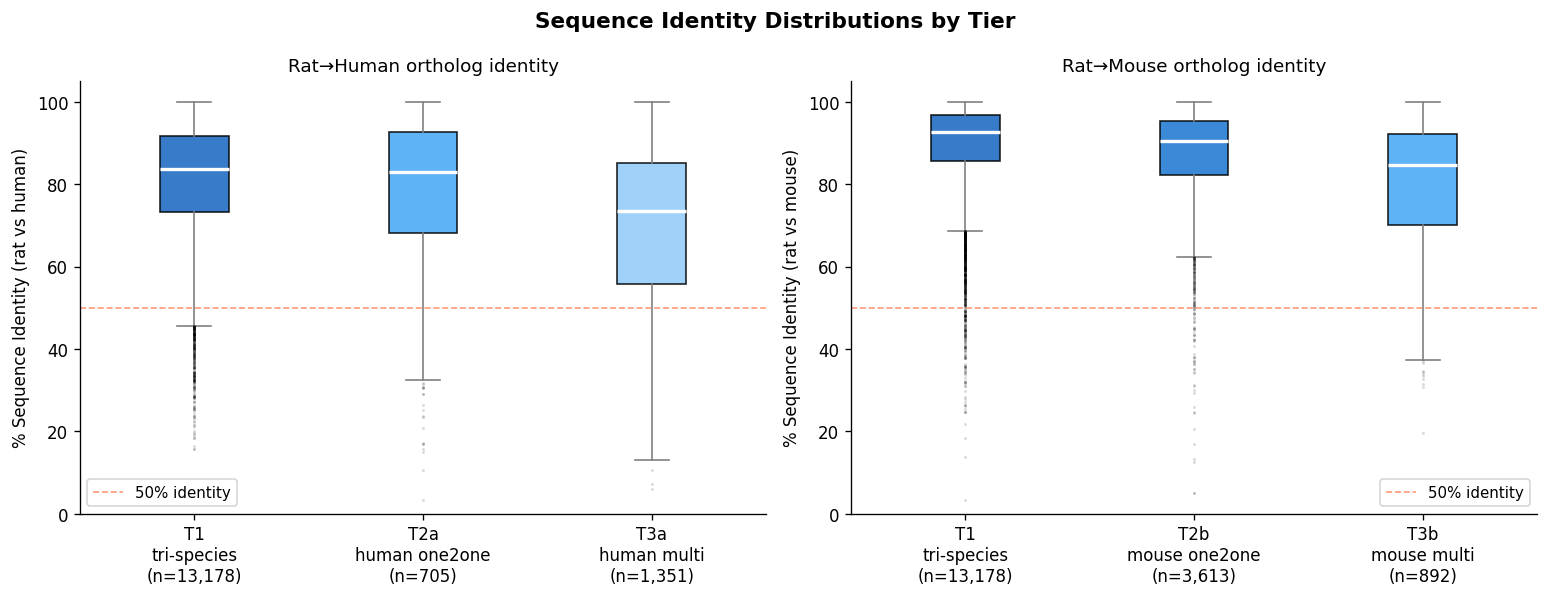

In [ ]:
# Load actual identity values from rat_token_mapping.tsv
tiers_human = {}; tiers_mouse = {}
with open(ORTH_DIR / 'rat_token_mapping.tsv') as f:
    for row in csv.DictReader(f, delimiter='\t'):
        tier = row['tier']
        ph = float(row['perc_id_human']) if row['perc_id_human'] else None
        pm = float(row['perc_id_mouse']) if row['perc_id_mouse'] else None
        tiers_human.setdefault(tier, [])
        tiers_mouse.setdefault(tier, [])
        if ph: tiers_human[tier].append(ph)
        if pm: tiers_mouse[tier].append(pm)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Sequence Identity Distributions by Tier', fontsize=13, fontweight='bold')

# Left: Human identity
ax = axes[0]
lh = ['T1\ntri-species\n(n=13,178)', 'T2a\nhuman one2one\n(n=705)', 'T3a\nhuman multi\n(n=1,351)']
dh = [tiers_human['T1_tri_species'], tiers_human['T2a_human_one2one'], tiers_human['T3a_human_multi']]
ch = ['#1565C0', '#42A5F5', '#90CAF9']
bp = ax.boxplot(dh, tick_labels=lh, patch_artist=True,
                medianprops=dict(color='white', linewidth=2),
                whiskerprops=dict(color='gray'), capprops=dict(color='gray'),
                flierprops=dict(marker='.', alpha=0.15, markersize=1.5))
for patch, c in zip(bp['boxes'], ch): patch.set_facecolor(c); patch.set_alpha(0.85)
ax.set_ylabel('% Sequence Identity (rat vs human)')
ax.set_title('Rat→Human ortholog identity', fontsize=11)
ax.set_ylim(0, 105)
ax.axhline(50, color='#FF7043', linestyle='--', linewidth=1, alpha=0.7, label='50% identity')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Right: Mouse identity
ax = axes[1]
lm = ['T1\ntri-species\n(n=13,178)', 'T2b\nmouse one2one\n(n=3,613)', 'T3b\nmouse multi\n(n=892)']
dm = [tiers_mouse['T1_tri_species'], tiers_mouse['T2b_mouse_one2one'], tiers_mouse['T3b_mouse_multi']]
cm = ['#1565C0', '#1976D2', '#42A5F5']
bp = ax.boxplot(dm, tick_labels=lm, patch_artist=True,
                medianprops=dict(color='white', linewidth=2),
                whiskerprops=dict(color='gray'), capprops=dict(color='gray'),
                flierprops=dict(marker='.', alpha=0.15, markersize=1.5))
for patch, c in zip(bp['boxes'], cm): patch.set_facecolor(c); patch.set_alpha(0.85)
ax.set_ylabel('% Sequence Identity (rat vs mouse)')
ax.set_title('Rat→Mouse ortholog identity', fontsize=11)
ax.set_ylim(0, 105)
ax.axhline(50, color='#FF7043', linestyle='--', linewidth=1, alpha=0.7, label='50% identity')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout(); plt.show()


## Token Space and Cross-Species Coverage

Stage 3 extends the GeneCompass 50,558-token vocabulary with **4,717 new rat-specific
tokens** (T4 genes), bringing the total to **55,275 tokens** for the rat fine-tuned model.

Cross-species coverage implications for downstream stages:
- **Stage 4 (gene medians):** genes with `rat→human` mapping use the human median
  pickle as normalization reference; genes with only `rat→mouse` fall back to mouse
  medians; T4 genes compute rat-native medians from Stage 2 quality-controlled h5ad directly
- **Stage 7 (fine-tuning):** T1 + T2 token embeddings are warm-started from
  GeneCompass pretrained weights; T4 tokens are randomly initialized
- **Aim 3 (cross-species translation):** confidence column restricts which rat→human
  comparisons are biologically trusted


In [ ]:
with open(ORTH_DIR / 'mapping_statistics.json') as f:
    stats = json.load(f)

# Pre-trained token reuse vs new
pretrained = stats['pre_trained_tokens_used']
new_tok    = stats['new_tokens_created']
gc_vocab   = 50558  # from human_mouse_tokens.pickle

print("Token space summary:")
print(f"  GeneCompass pretrained vocab : {gc_vocab:>6,} tokens")
print(f"  Rat genes → pre-trained tok  : {pretrained:>6,}  ({pretrained/stats['total_input_genes']*100:.1f}%)")
print(f"  Rat genes → NEW token (T4)   : {new_tok:>6,}  ({new_tok/stats['total_input_genes']*100:.1f}%)")
print(f"  Extended vocab size          : {gc_vocab + new_tok:>6,} tokens")
print()
print("Cross-species coverage:")
print(f"  rat→human mappings           : {stats['rat_to_human_mappings']:>6,}  ({stats['rat_to_human_mappings']/stats['total_input_genes']*100:.1f}%)")
print(f"  rat→mouse mappings           : {stats['rat_to_mouse_mappings']:>6,}  ({stats['rat_to_mouse_mappings']/stats['total_input_genes']*100:.1f}%)")
print(f"  T4 (no ortholog)             : {stats['tier_distribution']['T4_new_token']:>6,}  ({stats['tier_distribution']['T4_new_token']/stats['total_input_genes']*100:.1f}%)")
print()

# Biotype breakdown across tiers
with open(ORTH_DIR / 'tier_diagnostics.json') as f:
    diag = json.load(f)
print("Biotype by tier:")
tier_order = ['T1_tri_species','T2a_human_one2one','T2b_mouse_one2one',
              'T3a_human_multi','T3b_mouse_multi','T4_new_token']
print(f"  {'Tier':<25s} {'protein_coding':>15s} {'lncrna':>8s} {'mirna':>7s}")
for t in tier_order:
    bd = diag['tier_statistics'][t]['biotype_breakdown']
    pc  = bd.get('protein_coding', 0)
    lnc = bd.get('lncrna', 0)
    mir = bd.get('mirna', 0)
    print(f"  {t:<25s} {pc:>15,} {lnc:>8,} {mir:>7,}")

# Sample rows from rat_token_mapping.tsv
print()
print("Sample rows from rat_token_mapping.tsv:")
with open(ORTH_DIR / 'rat_token_mapping.tsv') as f:
    reader = csv.DictReader(f, delimiter='\t')
    cols = ['rat_gene','rat_symbol','tier','token_id','perc_id_human','perc_id_mouse','confidence']
    print('  ' + '\t'.join(f'{c}' for c in cols))
    for i, row in enumerate(reader):
        if i >= 5: break
        vals = [row.get(c,'') for c in cols]
        print('  ' + '\t'.join(vals))


Token space summary:
  GeneCompass pretrained vocab : 50,558 tokens
  Rat genes → pre-trained tok  : 17,496  (78.8%)
  Rat genes → NEW token (T4)   :  4,717  (21.2%)
  Extended vocab size          : 55,275 tokens

Cross-species coverage:
  rat→human mappings           : 15,234  (68.6%)
  rat→mouse mappings           : 17,839  (80.3%)
  T4 (no ortholog)             :  2,474  (11.1%)

Biotype by tier:
  Tier                       protein_coding   lncrna   mirna
  T1_tri_species                     13,178        0       0
  T2a_human_one2one                     589        0     116
  T2b_mouse_one2one                   3,613        0       0
  T3a_human_multi                     1,347        0       4
  T3b_mouse_multi                       892        0       0
  T4_new_token                        1,108    1,275      91

Sample rows from rat_token_mapping.tsv:
  rat_gene	rat_symbol	tier	token_id	perc_id_human	perc_id_mouse	confidence
  ENSRNOG00000000001	Arsj	T1_tri_species	6885	90.2848	

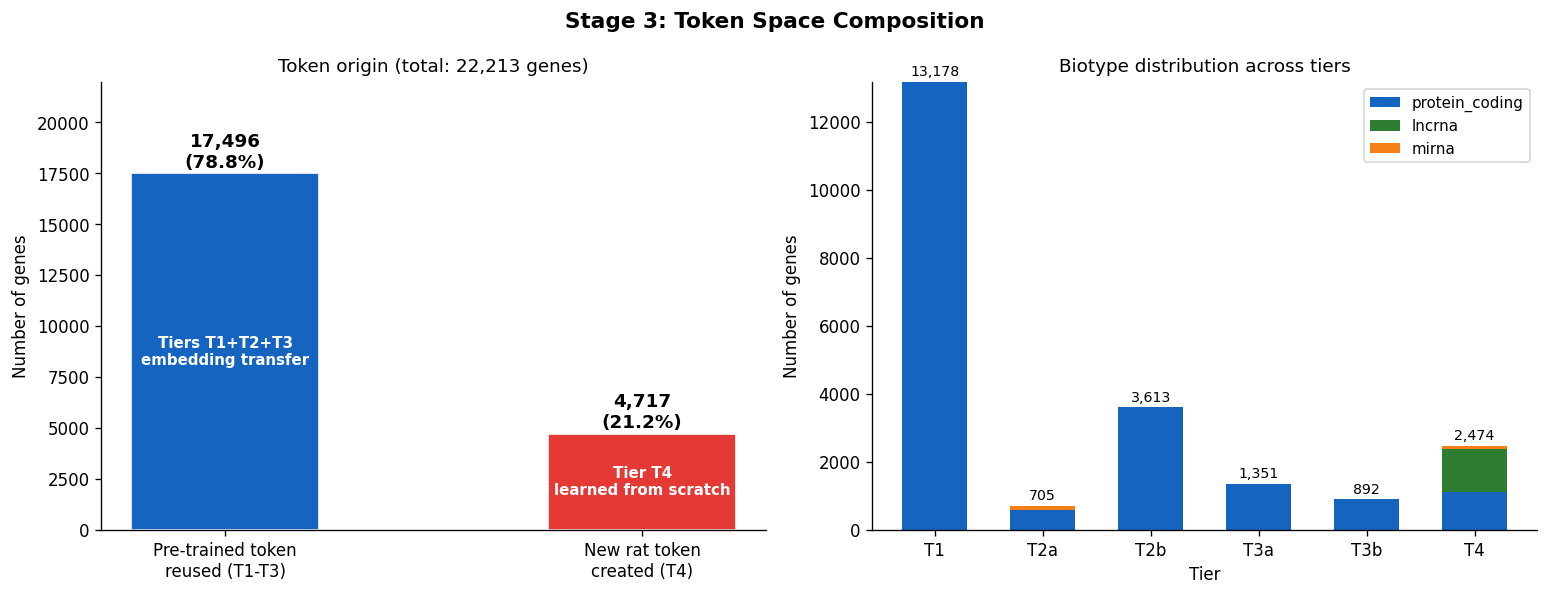

In [ ]:
with open(ORTH_DIR / 'mapping_statistics.json') as f:
    stats = json.load(f)
with open(ORTH_DIR / 'tier_diagnostics.json') as f:
    diag = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Stage 3: Token Space Composition', fontsize=13, fontweight='bold')

ax = axes[0]
cats = ['Pre-trained token\nreused (T1-T3)', 'New rat token\ncreated (T4)']
vals = [stats['pre_trained_tokens_used'], stats['new_tokens_created']]
clrs = ['#1565C0', '#E53935']
bars = ax.bar(cats, vals, color=clrs, width=0.45, edgecolor='white')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{v:,}\n({v/sum(vals)*100:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.text(0, vals[0]/2, f'Tiers T1+T2+T3\nembedding transfer', ha='center', va='center',
        fontsize=9, color='white', fontweight='bold')
ax.text(1, vals[1]/2, 'Tier T4\nlearned from scratch', ha='center', va='center',
        fontsize=9, color='white', fontweight='bold')
ax.set_ylabel('Number of genes')
ax.set_title(f'Token origin (total: {sum(vals):,} genes)', fontsize=11)
ax.set_ylim(0, 22000)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

ax = axes[1]
tier_order = ['T1_tri_species','T2a_human_one2one','T2b_mouse_one2one',
              'T3a_human_multi','T3b_mouse_multi','T4_new_token']
tier_labels_short = ['T1','T2a','T2b','T3a','T3b','T4']
pc  = [diag['tier_statistics'][t]['biotype_breakdown'].get('protein_coding',0) for t in tier_order]
lnc = [diag['tier_statistics'][t]['biotype_breakdown'].get('lncrna',0) for t in tier_order]
mir = [diag['tier_statistics'][t]['biotype_breakdown'].get('mirna',0) for t in tier_order]
x = np.arange(len(tier_order)); width = 0.6
b1 = ax.bar(x, pc, width, label='protein_coding', color='#1565C0')
b2 = ax.bar(x, lnc, width, bottom=pc, label='lncrna', color='#2E7D32')
b3 = ax.bar(x, mir, width, bottom=[p+l for p,l in zip(pc,lnc)], label='mirna', color='#F57F17')
ax.set_xticks(x); ax.set_xticklabels(tier_labels_short, fontsize=10)
ax.set_xlabel('Tier'); ax.set_ylabel('Number of genes')
ax.set_title('Biotype distribution across tiers', fontsize=11)
ax.legend(fontsize=9)
for i, (p,l,m) in enumerate(zip(pc,lnc,mir)):
    tot = p+l+m
    if tot > 0: ax.text(i, tot+80, f'{tot:,}', ha='center', va='bottom', fontsize=8.5)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout(); plt.show()


## Stage 3 Summary

`stage3_manifest.json` records the complete provenance of the mapping, including
input MD5s, config snapshot, and output file sizes. The key downstream handoffs are:

| Stage/Aim | File consumed | Purpose |
|-----------|--------------|---------|
| Stage 4 | `rat_to_human_mapping.pickle` | Choose human vs rat median for each gene |
| Stage 5 | `rat_tokens.pickle` | Tokenize quality-controlled cells → ranked gene lists |
| Aim 2 (GRN) | `confidence` column | Flag low-confidence edges in GRN reconstruction |
| Aim 3 (translation) | `confidence` column | Restrict cross-species translation to high-confidence genes |


In [ ]:
with open(ORTH_DIR / 'stage3_manifest.json') as f:
    manifest = json.load(f)

print(f"stage3_manifest.json  (generated {manifest['timestamp'][:10]})")
print(f"  git hash : {manifest['git_hash'][:12]}")
print()
print("  Input checksums:")
for fname, md5 in manifest['input_checksums'].items():
    print(f"    {fname:<40s} {md5}")
print()
print("  Tier counts:")
for tier, cnt in sorted(manifest['tier_counts'].items(), key=lambda x: -x[1]):
    print(f"    {tier:<25s} {cnt:>6,}")
print()
print("  Outputs:")
for fname, n in manifest['outputs'].items():
    print(f"    {fname:<40s} {n:>6,}")
print()
print("  Downstream:")
for stage, desc in manifest['downstream'].items():
    print(f"    {stage}: {desc}")


stage3_manifest.json  (generated 2026-04-01)
  git hash : b9e1d760f072

  Input checksums:
    pruned_gene_universe.tsv                 1caa6bda23b0e83a5c28902392c50de4
    rat_human_orthologs.tsv                  88d44d064f6a89e3f4fd81ce6064bb19
    rat_mouse_orthologs.tsv                  1e14155079d42a197e8d97de61050f64
    genecompass_tokens                       95e86206934cc7ba507bb79b933e04ea
    genecompass_homologs                     da950ff95e2305db5b512dddfef0375d

  Tier counts:
    T1_tri_species            13,178
    T2b_mouse_one2one          3,613
    T4_new_token               2,474
    T3a_human_multi            1,351
    T3b_mouse_multi              892
    T2a_human_one2one            705

  Outputs:
    rat_token_mapping.tsv                    22,213
    rat_tokens.pickle                        22,213
    rat_to_human_mapping.pickle              15,234
    rat_to_mouse_mapping.pickle              17,839
    new_rat_tokens.txt                        4,717

  Downst

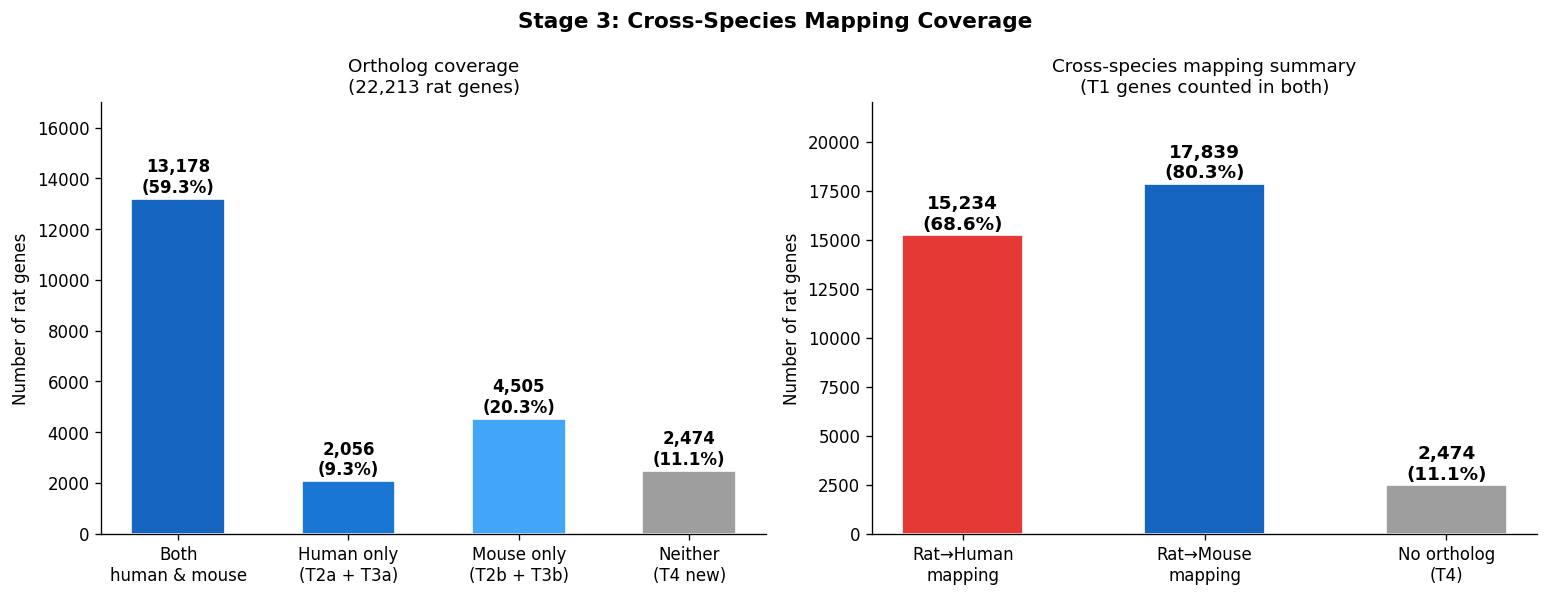

In [ ]:
with open(ORTH_DIR / 'mapping_statistics.json') as f:
    stats = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Stage 3: Cross-Species Mapping Coverage', fontsize=13, fontweight='bold')

ax = axes[0]
cov_labels = ['Both\nhuman & mouse', 'Human only\n(T2a + T3a)', 'Mouse only\n(T2b + T3b)', 'Neither\n(T4 new)']
cov_vals   = [
    stats['tier_distribution']['T1_tri_species'],              # both (T1 = confirmed both)
    stats['tier_distribution']['T2a_human_one2one'] + stats['tier_distribution']['T3a_human_multi'],  # human only
    stats['tier_distribution']['T2b_mouse_one2one'] + stats['tier_distribution']['T3b_mouse_multi'],  # mouse only
    stats['tier_distribution']['T4_new_token'],               # neither
]
cov_colors = ['#1565C0','#1976D2','#42A5F5','#9E9E9E']
total_genes = stats['total_input_genes']
bars = ax.bar(cov_labels, cov_vals, color=cov_colors, width=0.55, edgecolor='white')
for bar, v in zip(bars, cov_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{v:,}\n({v/total_genes*100:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Number of rat genes')
ax.set_title(f'Ortholog coverage\n({total_genes:,} rat genes)', fontsize=11)
ax.set_ylim(0, 17000)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

ax = axes[1]
x_cov = [0, 1, 2]
lc = ['Rat→Human\nmapping', 'Rat→Mouse\nmapping', 'No ortholog\n(T4)']
vc = [stats['rat_to_human_mappings'], stats['rat_to_mouse_mappings'],
      stats['tier_distribution']['T4_new_token']]
cc = ['#E53935','#1565C0','#9E9E9E']
bars = ax.bar(x_cov, vc, color=cc, width=0.5, edgecolor='white')
for bar, v in zip(bars, vc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{v:,}\n({v/total_genes*100:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_xticks(x_cov); ax.set_xticklabels(lc, fontsize=10)
ax.set_ylabel('Number of rat genes')
ax.set_title('Cross-species mapping summary\n(T1 genes counted in both)', fontsize=11)
ax.set_ylim(0, 22000)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout(); plt.show()


## Stage Summary

Stage 3 assigns each retained rat gene to an explicit mapping tier and records whether its representation reuses a pretrained token or requires a new rat token. Sequence-identity and biotype diagnostics make the mapping coverage and its limitations visible before model construction.


---
## Reproducibility Notes

| Item | Value |
|------|-------|
| Python version | 3.12 |
| Key packages | `pandas`, `numpy`, `pickle`, `pybiomart` |
| Ensembl BioMart release | 113 |
| Genome assembly | mRatBN7.2 (*Rattus norvegicus*) |
| Stage 3 manifest date | 2026-04-01 |
| GeneCompass prior knowledge | `vendor/GeneCompass/prior_knowledge/` |
| Config file | `config/pipeline_config.yaml` — `orthologs`, `biomart`, and `paths` sections |

**To re-run Stage 3 from scratch:**
```bash
export PIPELINE_ROOT=..
source ../motrpac-env/bin/activate
cd $PIPELINE_ROOT
python pipeline/run_stage3.py                    # full ortholog mapping run
python pipeline/run_stage3.py --dry-run          # validate inputs/config only
python pipeline/run_stage3.py -v                 # verbose logging
```

**Known considerations:**
- Stage 3 depends on Stage 2's `data/training/gene_universe/pruned_gene_universe.tsv` and Stage 1 BioMart ortholog tables.
- GeneCompass vocabulary files must be present under `vendor/GeneCompass/prior_knowledge/` before rerunning.
- The tier assignment intentionally uses Ensembl orthology as the gate and does not impose an additional sequence-identity threshold.
